# Jupyter Notebooks and Python
https://ambermd.org/tutorials/Jupyter.php

## Interactive data analysis with pytraj/cpptraj and Jupyter notebook
https://ambermd.org/tutorials/analysis/tutorial_notebooks/pytraj_notebook/index.html

In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) # avoid warning message to make the notebook nicer
import pytraj as pt
import matplotlib.pyplot as plt

### Computing RMSD, using 1st frame as reference

In [64]:
traj = pt.load('B2/trial5_tleap_script_parm7_rst7/o98_prod_md.nc', top='B2/trial5_tleap_script_parm7_rst7/amber_o98_ion.parm7')
print(traj)

pytraj.Trajectory, 50 frames: 
Size: 0.063267 (GB)
<Topology: 56610 atoms, 13351 residues, 13059 mols, PBC with box type = octahedral>
           


#### Larger protein

In [45]:
data_rmsd_first = pt.rmsd(traj, ref=0, mask=":1-242&!@H*")
print(data_rmsd_first)

[1.07248748e-06 2.23129721e+00 2.14445523e+00 ... 4.26786025e+00
 3.94806568e+00 3.79214486e+00]


Text(0, 0.5, 'RMSD (Angstrom)')

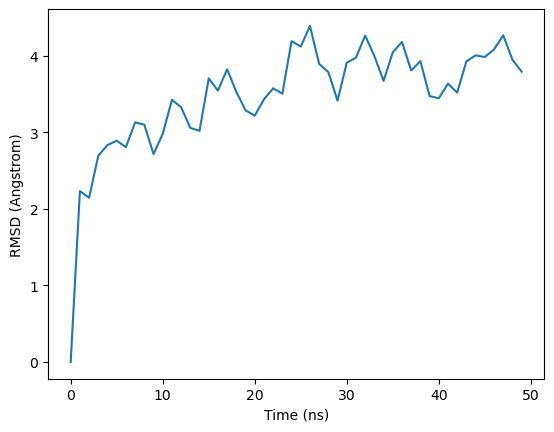

In [46]:
plt.plot(data_rmsd_first)
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (Angstrom)')

#### Smaller protein

In [56]:
data_rmsd_small_first = pt.rmsd(traj, ref=0, mask=":243-294&!@H*")
print(data_rmsd_small_first)

[5.77787206e-07 2.63522632e+00 2.68236001e+00 ... 1.10363407e+01
 1.00942413e+01 1.02570128e+01]


Text(0, 0.5, 'RMSD (Angstrom)')

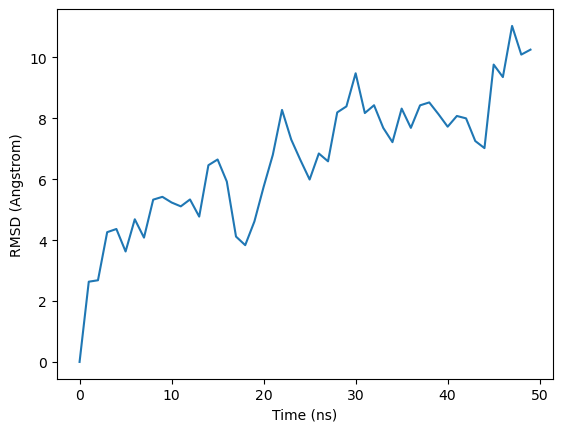

In [57]:
plt.plot(data_rmsd_small_first)
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (Angstrom)')

### Computing RMSD to a Reference

In [7]:
# we can reuse loaded topology from `traj`
ref = pt.load('B2/trial5_tleap_script_parm7_rst7/amber_o98_ion.rst7', top=traj.top)
print(ref)

pytraj.Trajectory, 1 frames: 
Size: 0.001265 (GB)
<Topology: 56610 atoms, 13351 residues, 13059 mols, PBC with box type = octahedral>
           


#### larger protein

In [43]:
data_rmsd_ref = pt.rmsd(traj, ref=ref, mask=":1-242&!@H*")
print(data_rmsd_ref)

[2.89036007 3.00808573 2.90039336 ... 4.17042135 3.99683311 3.86438767]


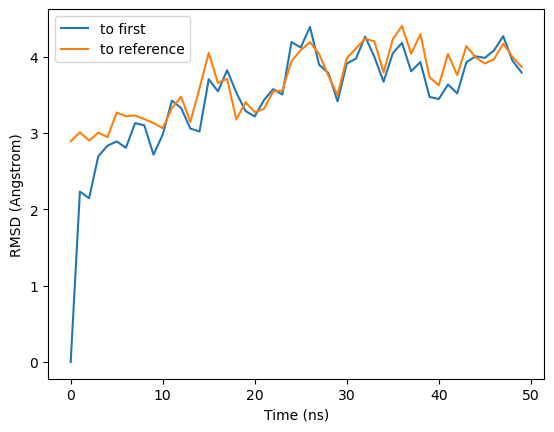

In [47]:
plt.plot(data_rmsd_first, label='to first')
plt.plot(data_rmsd_ref, label='to reference')
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (Angstrom)')
plt.legend()

#### smaller protein

In [65]:
data_rmsd_small_ref = pt.rmsd(traj, ref=ref, mask=":243-294&!@H*")
print(data_rmsd_small_ref)

[4.12973214 3.23366101 3.79109737 ... 8.93124825 8.22628099 8.1806252 ]


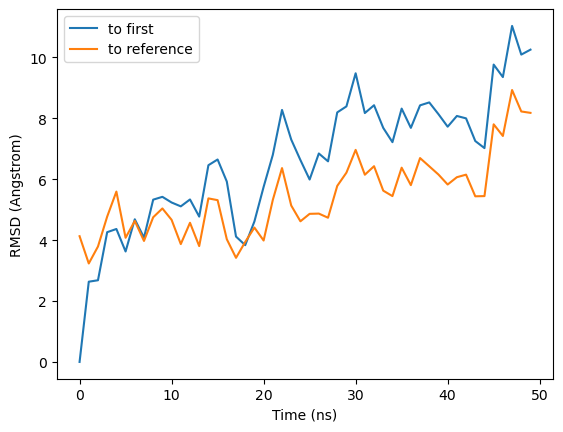

In [66]:
plt.plot(data_rmsd_small_first, label='to first')
plt.plot(data_rmsd_small_ref, label='to reference')
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (Angstrom)')
plt.legend()

### Computing pairwise RMSD for specific snapshots

#### larger protein

In [67]:
# compute pairwise RMSD for first 50 snapshots(?) and skip every 1 frame
mat = pt.pairwise_rmsd(traj, mask=":1-242&!@H*", frame_indices=range(0, 50, 1))
print(mat, len(mat), sep='\n')

[[0.        2.2312973 2.1444552 ... 4.2678604 3.9480658 3.7921448]
 [2.2312973 0.        1.862775  ... 3.767705  3.6710098 3.7230768]
 [2.1444552 1.862775  0.        ... 4.118956  3.7887104 3.7815342]
 ...
 [4.2678604 3.767705  4.118956  ... 0.        1.719994  2.165631 ]
 [3.9480658 3.6710098 3.7887104 ... 1.719994  0.        1.7320207]
 [3.7921448 3.7230768 3.7815342 ... 2.165631  1.7320207 0.       ]]
50


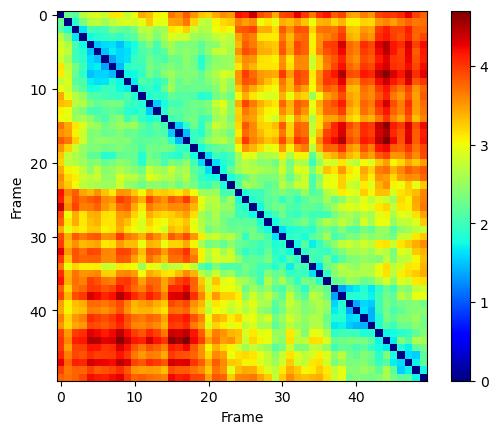

In [68]:
plt.imshow(mat, cmap='jet')
plt.xlabel('Frame')
plt.ylabel('Frame')
plt.colorbar()

### Computing dihedral angles

In [22]:
phipsi = pt.multidihedral(traj, resrange='1-12', dihedral_types="phi psi", dtype='dataframe')
phipsi[['phi_4', 'psi_4', 'phi_5', 'psi_5']].head()

,phi_4,psi_4,phi_5,psi_5
0,-49.548078,129.567399,-51.806685,141.096966
1,-52.014379,141.960906,-77.136228,160.380908
2,-40.984522,132.495217,-62.632648,132.830689
3,-64.767861,141.566592,-60.106684,155.748814
4,-56.163110,161.960962,-95.444718,156.856163


In [23]:
phipsi[['phi_4', 'psi_4', 'phi_5', 'psi_5']].describe()

,phi_4,psi_4,phi_5,psi_5
count,50.000000,50.000000,50.000000,50.000000
mean,-90.051759,147.794261,-67.908530,135.408910
std,64.280096,12.488190,11.984078,64.637472
min,-178.507718,113.847280,-95.444718,-173.940737
25%,-157.529461,139.517397,-74.925692,139.150702
50%,-63.115755,147.754309,-66.652385,146.132384
75%,-55.059802,158.251959,-59.537397,156.579955
max,178.922693,171.947948,-47.259625,179.881341


Text(0, 0.5, 'Phi (residue 4)')

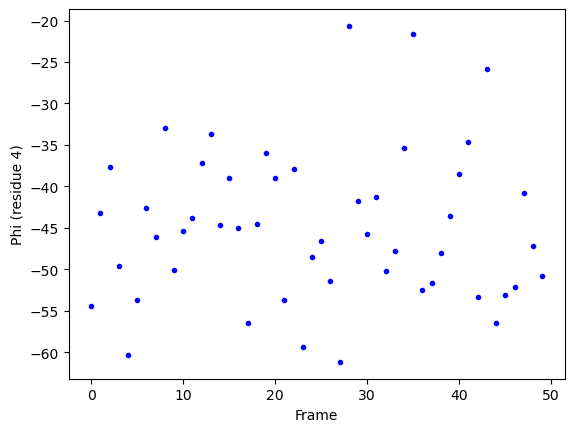

In [25]:
plt.plot(phipsi['psi_8'], '-bo', markersize=3, linewidth=0)
plt.xlabel('Frame')
plt.ylabel('Phi (residue 4)')

### Get some information about the structure

In [26]:
top = traj.top

for residue in top.residues:
    # Note: In python, 0-based index is used.
    # For example: SER0 should be first residue
    print(residue)

<MET0, 19 atoms>
<ALA1, 10 atoms>
<VAL2, 16 atoms>
<ALA3, 10 atoms>
<PRO4, 14 atoms>
<THR5, 14 atoms>
<ALA6, 10 atoms>
<ARG7, 24 atoms>
<GLU8, 15 atoms>
<GLU9, 15 atoms>
<ASN10, 14 atoms>
<VAL11, 16 atoms>
<TYR12, 21 atoms>
<MET13, 17 atoms>
<ALA14, 10 atoms>
<LYS15, 22 atoms>
<LEU16, 19 atoms>
<ALA17, 10 atoms>
<GLU18, 15 atoms>
<GLN19, 17 atoms>
<ALA20, 10 atoms>
<GLU21, 15 atoms>
<ARG22, 24 atoms>
<TYR23, 21 atoms>
<GLU24, 15 atoms>
<GLU25, 15 atoms>
<MET26, 17 atoms>
<VAL27, 16 atoms>
<GLU28, 15 atoms>
<PHE29, 20 atoms>
<MET30, 17 atoms>
<GLU31, 15 atoms>
<LYS32, 22 atoms>
<VAL33, 16 atoms>
<SER34, 11 atoms>
<ASN35, 14 atoms>
<SER36, 11 atoms>
<LEU37, 19 atoms>
<GLY38, 7 atoms>
<SER39, 11 atoms>
<GLU40, 15 atoms>
<GLU41, 15 atoms>
<LEU42, 19 atoms>
<THR43, 14 atoms>
<VAL44, 16 atoms>
<GLU45, 15 atoms>
<GLU46, 15 atoms>
<ARG47, 24 atoms>
<ASN48, 14 atoms>
<LEU49, 19 atoms>
<LEU50, 19 atoms>
<SER51, 11 atoms>
<VAL52, 16 atoms>
<ALA53, 10 atoms>
<TYR54, 21 atoms>
<LYS55, 22 atoms>
<AS

In [27]:
list(traj.top.atoms)[:10]

[Atom(name=N, type=N3, atomic_number=7, index=0, resid=0),
 Atom(name=H1, type=H, atomic_number=1, index=1, resid=0),
 Atom(name=H2, type=H, atomic_number=1, index=2, resid=0),
 Atom(name=H3, type=H, atomic_number=1, index=3, resid=0),
 Atom(name=CA, type=CX, atomic_number=6, index=4, resid=0),
 Atom(name=HA, type=HP, atomic_number=1, index=5, resid=0),
 Atom(name=CB, type=2C, atomic_number=6, index=6, resid=0),
 Atom(name=HB2, type=HC, atomic_number=1, index=7, resid=0),
 Atom(name=HB3, type=HC, atomic_number=1, index=8, resid=0),
 Atom(name=CG, type=2C, atomic_number=6, index=9, resid=0)]

## Interactive data analysis with NGLView, pytraj and Jupyter notebook
https://ambermd.org/tutorials/analysis/tutorial_notebooks/nglview_notebook/index.html

In [29]:
import warnings
warnings.filterwarnings('ignore') # make the notebook nicer
import pytraj as pt
import nglview as nv

print("nglview version = {}".format(nv.__version__))
print("pytraj version = {}".format(pt.__version__))

nglview version = 3.0.6
pytraj version = 2.0.6


### View an AMBER trajectory

In [69]:
view = nv.show_pytraj(traj)
view

NGLWidget(max_frame=49)

In [70]:
view.render_image()

Image(value=b'', width='99%')

In [71]:
# superpose to 1st frame, using only CA atoms
#traj.superpose(ref=0, mask='@CA')

view2 = nv.show_pytraj(traj)
view2.clear_representations()
view2.add_representation('cartoon')
view2.add_representation('licorice', selection='not hydrogen')
view2

NGLWidget(max_frame=49)

### Replicate cells in a new trajectory

In [34]:
traj1 = pt.replicate_cell(traj, direction=('001', '111'))
traj1

pytraj.Trajectory, 50 frames: 
Size: 0.126533 (GB)
<Topology: 113220 atoms, 26702 residues, 26118 mols, non-PBC>
           

In [115]:
view3 = nv.show_pytraj(traj1)
view3.representations = []
view3.add_representation('cartoon', selection='protein')#, color='blue')
#view3.add_representation('line', selection='water')
view3

NGLWidget(max_frame=49)

In [114]:
view3

NGLWidget(max_frame=49, n_components=1)

In [109]:
traj_replicateAllCells = pt.replicate_cell(traj, direction='all')
traj_replicateAllCells

pytraj.Trajectory, 50 frames: 
Size: 1.708198 (GB)
<Topology: 1528470 atoms, 360477 residues, 352593 mols, non-PBC>
           

In [111]:
view4 = nv.show_pytraj(traj_replicateAllCells)
view4.representations = []
view4.add_representation('cartoon', selection='protein')#, color='blue')
#view4.add_representation('line', selection='water')
view4

NGLWidget(max_frame=49)

In [112]:
view4

NGLWidget(max_frame=49, n_components=1)

In [118]:
del(traj_replicateAllCells)

In [108]:
traj1_1 = pt.replicate_cell(traj, direction='dir 001 dir 111')
traj1_1

pytraj.Trajectory, 50 frames: 
Size: 0.126533 (GB)
<Topology: 113220 atoms, 26702 residues, 26118 mols, non-PBC>
           

In [116]:
del(traj1_1)

In [100]:
traj1_2 = pt.replicate_cell(traj, direction='dir 001 dir 1-10')
traj1_2

pytraj.Trajectory, 50 frames: 
Size: 0.126533 (GB)
<Topology: 113220 atoms, 26702 residues, 26118 mols, non-PBC>
           

In [117]:
del(traj1_2)

## Trajectory analysis
http://amber-md.github.io/pytraj/latest/tutorials/tutorial_autoimage.html

https://amber-md.github.io/pytraj/latest/_api/pytraj.html

http://amber-md.github.io/pytraj/latest/modify_traj.html

https://amber-md.github.io/pytraj/latest/analysis

Before any edits to trajectory

In [73]:
traj.xyz[0, 0]

array([29.16452049,  8.33182979, 24.13882465])

### `.autoimage()` protein

In [74]:
traj2 = pt.autoimage(traj)
print(traj2, traj2.xyz[0, 0], sep = '\n')

pytraj.Trajectory, 50 frames: 
Size: 0.063267 (GB)
<Topology: 56610 atoms, 13351 residues, 13059 mols, PBC with box type = octahedral>
           
[67.80285049 52.47955663 66.01957705]


In [83]:
view5 = nv.show_pytraj(traj2)
view5.representations = []
view5.add_representation('cartoon', selection='protein')
view5.add_representation('licorice', selection='not hydrogen')
view5

NGLWidget(max_frame=49)

### `.transform()` protein

In [76]:
traj3 = traj.transform(['autoimage', 'center @CA origin', 'translate x 1.2'])
traj3.xyz[0, 0]

array([29.16452049,  8.33182979, 24.13882465])

In [84]:
view6 = nv.show_pytraj(traj3)
view6.representations = []
view6.add_representation('cartoon', selection='protein')
view6.add_representation('licorice', selection='not hydrogen')
view6

NGLWidget(max_frame=49)

In [82]:
pt.unwrap()

AttributeError: module 'pytraj' has no attribute 'unwrap'

### Distance between residues

#### Before fixing smaller protein "flying out" (seeing the next periodic image)

In [87]:
view7 = nv.show_pytraj(traj)
view7.representations = []
view7.add_representation('cartoon', selection='protein')
view7

NGLWidget(max_frame=49)

Distance between residue 217 and 281

Looks like the maximum separation in the last frame

In [120]:
max_dists = pt.distance(traj, mask=':217 :281', frame_indices=range(0, 50, 1))
print(max_dists, len(max_dists), sep='\n')

[46.17978481 49.47931947 48.68392443 ... 85.24756702 82.69439343
 94.80398672]
50


Text(0, 0.5, 'Distance (residues 217 and 281) (Angstrom)')

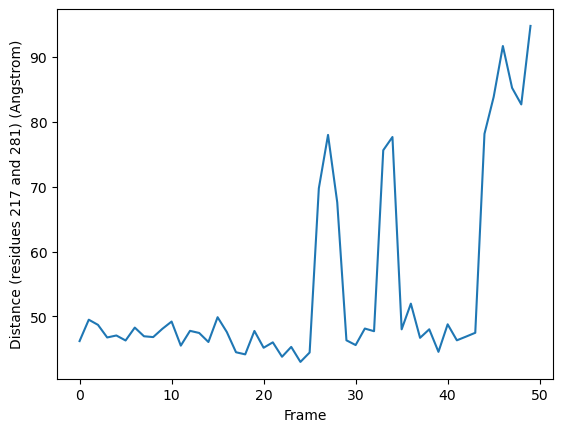

In [122]:
plt.plot(max_dists)
plt.xlabel('Time (ns)')
plt.ylabel('Distance (residues 217 and 281) (Angstrom)')

In [126]:
traj.top.box

<Box: octahedral, (x, y, z, alpha, beta, gamma) = (86.5841454, 86.5841454, 86.5841454, 109.471219, 109.471219, 109.471219)>

Seems like the "jumps" are due to `pytraj` calculating distances between the periodic images and not the intermolecular distance

#### Centre protein system with `cpptraj`
Prevent appearance of periodic image

##### With the original topology (solvated protein system) and production MD trajectory

```sh
> unwrap *                                             
  [unwrap *]
    UNWRAP: By atom using mask '*'
        Reference is first frame.
> center * mass origin
  [center * mass origin]
    CENTER: Centering coordinates using center of mass of atoms in mask (*) to
        coordinate origin.
> image origin center familiar
  [image origin center familiar]
    IMAGE: By molecule to origin based on center of mass using all atoms
           Triclinic On, familiar shape.
> trajout o98_unwrap_prod_md.nc
  [trajout o98_unwrap_prod_md.nc]
        Writing 'o98_unwrap_prod_md.nc' as Amber NetCDF
> go  
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_o98_ion.parm7, 56610 atoms, 13351 res, box: Truncated octahedron, 13059 mol, 12955 solvent

INPUT TRAJECTORIES (1 total):
 0: 'o98_prod_md.nc' is a NetCDF AMBER trajectory with coordinates, time, box, Parm amber_o98_ion.parm7 (Truncated octahedron box) (reading 50 of 50)
  Coordinate processing will occur on 50 frames.

OUTPUT TRAJECTORIES (1 total):
  'o98_unwrap_prod_md.nc' (50 frames) is a NetCDF AMBER trajectory

BEGIN TRAJECTORY PROCESSING:
.....................................................
ACTION SETUP FOR PARM 'amber_o98_ion.parm7' (3 actions):
  0: [unwrap *]
        Mask [*] corresponds to 56610 atoms.
        Number of atoms to be unwrapped is 56610
  1: [center * mass origin]
        Mask [*] corresponds to 56610 atoms.
  2: [image origin center familiar]
        Mask [*] corresponds to 56610 atoms.
        Number of molecules to be imaged is 13059
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  o98_unwrap_prod_md.nc (coordinates, time, box)
----- o98_prod_md.nc (1-50, 1) -----
 0% 10% 20% 31% 41% 51% 61% 71% 82% 92% 100% Complete.

Read 50 frames and processed 50 frames.
TIME: Avg. throughput= 52.3781 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0005 seconds.

DATASETS (1 total):
        end-to-end "end-to-end" (double, distance), size is 50 (0.400 kB)
    Total data set memory usage is at least 0.400 kB

DATAFILES (1 total):
  dist-end-to-end.agr (Grace File):  end-to-end

RUN TIMING:
TIME:           Init               : 0.1183 s ( 10.99%)
TIME:           Trajectory Process : 0.9546 s ( 88.68%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0005 s (  0.05%)
TIME:           Data File Write    : 0.0025 s (  0.23%)
TIME:           Other              : 0.0005 s (  0.00%)
TIME:   Run Total 1.0765 s
---------- RUN END ---------------------------------------------------
> exit
  [exit]
--------------------------------------------------------------------------------
To cite CPPTRAJ use:
Daniel R. Roe and Thomas E. Cheatham, III, "PTRAJ and CPPTRAJ: Software for
  Processing and Analysis of Molecular Dynamics Trajectory Data". J. Chem.
  Theory Comput., 2013, 9 (7), pp 3084-3095.
```

##### Keep only the proteins
Remove water and ions, because these seem to hinder proper centering

Also beneficial to keep file sizes small\
Most generic analyses do NOT require solvent, unless solvent-protein interaction is the goal

```sh
wjoon21@puma:~/project/chen2023_possible_allosteric/B2/trial5_tleap_script_parm7_rst7$ cpptraj -p amber_o98_ion.parm7 -y o98_prod_md.nc 

CPPTRAJ: Trajectory Analysis. V6.4.4 (AmberTools)
    ___  ___  ___  ___
     | \/ | \/ | \/ | 
    _|_/\_|_/\_|_/\_|_

| Date/time: 06/14/24 16:53:44
| Available memory: 239.804 MB

        Reading 'amber_o98_ion.parm7' as Amber Topology
        Radius Set: modified Bondi radii (mbondi)
        Reading 'o98_prod_md.nc' as Amber NetCDF
        Loading previous history from log 'cpptraj.log'
> strip :WAT,Na+,Cl- parmout o98_prod_md_dry.parm7
  [strip :WAT,Na+,Cl- parmout o98_prod_md_dry.parm7]
    STRIP: Stripping atoms in mask [:WAT,Na+,Cl-]
        Writing 'stripped' topology file with name 'o98_prod_md_dry.parm7'
> unwrap *
  [unwrap *]
    UNWRAP: By atom using mask '*'
        Reference is first frame.
> center * mass origin
  [center * mass origin]
    CENTER: Centering coordinates using center of mass of atoms in mask (*) to
        coordinate origin.
> image origin center familiar                    
  [image origin center familiar]
    IMAGE: By molecule to origin based on center of mass using all atoms
           Triclinic On, familiar shape.
> trajout o98_unwrap_prod_md_dry.nc               
  [trajout o98_unwrap_prod_md_dry.nc]
        Writing 'o98_unwrap_prod_md_dry.nc' as Amber NetCDF
> go
  [go]
---------- RUN BEGIN -------------------------------------------------

PARAMETER FILES (1 total):
 0: amber_o98_ion.parm7, 56610 atoms, 13351 res, box: Truncated octahedron, 13059 mol, 12955 solvent

INPUT TRAJECTORIES (1 total):
 0: 'o98_prod_md.nc' is a NetCDF AMBER trajectory with coordinates, time, box, Parm amber_o98_ion.parm7 (Truncated octahedron box) (reading 50 of 50)
  Coordinate processing will occur on 50 frames.

OUTPUT TRAJECTORIES (1 total):
  'o98_unwrap_prod_md_dry.nc' (50 frames) is a NetCDF AMBER trajectory

BEGIN TRAJECTORY PROCESSING:
.....................................................
ACTION SETUP FOR PARM 'amber_o98_ion.parm7' (4 actions):
  0: [strip :WAT,Na+,Cl- parmout o98_prod_md_dry.parm7]
        Stripping 51922 atoms.
        Stripped topology: 4688 atoms, 294 res, box: Truncated octahedron, 2 mol
        Writing topology 0 (amber_o98_ion.parm7) to 'o98_prod_md_dry.parm7' with format Amber Topology
        Memory used by full exclusion list: 102.248 kB
  1: [unwrap *]
        Mask [*] corresponds to 4688 atoms.
        Number of atoms to be unwrapped is 4688
  2: [center * mass origin]
        Mask [*] corresponds to 4688 atoms.
  3: [image origin center familiar]
        Mask [*] corresponds to 4688 atoms.
        Number of molecules to be imaged is 2
.....................................................
ACTIVE OUTPUT TRAJECTORIES (1):
  o98_unwrap_prod_md_dry.nc (coordinates, time, box)
----- o98_prod_md.nc (1-50, 1) -----
 0% 10% 20% 31% 41% 51% 61% 71% 82% 92% 100% Complete.

Read 50 frames and processed 50 frames.
TIME: Avg. throughput= 488.7586 frames / second.

ACTION OUTPUT:
TIME: Analyses took 0.0000 seconds.

RUN TIMING:
TIME:           Init               : 0.0001 s (  0.10%)
TIME:           Trajectory Process : 0.1023 s ( 99.73%)
TIME:           Action Post        : 0.0000 s (  0.00%)
TIME:           Analysis           : 0.0000 s (  0.00%)
TIME:           Data File Write    : 0.0000 s (  0.00%)
TIME:           Other              : 0.0002 s (  0.00%)
TIME:   Run Total 0.1026 s
---------- RUN END ---------------------------------------------------
```

NEXT time, if want to centre the protein without striping the solvent box,\
use `mask` flag to select only the protein residues instead of `*` (all residues, incl. solvent)\
for the `unwrap` and `center` commands

#### Load the "dried" topology and trajectory that has been fixed with `unwrap`

In [127]:
traj_dry = pt.load('B2/trial5_tleap_script_parm7_rst7/o98_unwrap_prod_md_dry.nc', top='B2/trial5_tleap_script_parm7_rst7/o98_prod_md_dry.parm7')
print(traj_dry)

pytraj.Trajectory, 50 frames: 
Size: 0.005239 (GB)
<Topology: 4688 atoms, 294 residues, 2 mols, PBC with box type = octahedral>
           


In [131]:
view_dry = nv.show_pytraj(traj_dry)
view_dry.representations = []
view_dry.add_representation('cartoon', selection='protein')
view_dry

NGLWidget(max_frame=49)

In [132]:
max_dists_dry = pt.distance(traj_dry, mask=':217 :281', frame_indices=range(0, 50, 1))
print(max_dists_dry, len(max_dists), sep='\n')

[46.17978501 49.47931955 48.6839237  ... 48.12807156 49.57888258
 47.95108292]
50


Text(0, 0.5, 'Distance (residues 217 and 281) (Angstrom)')

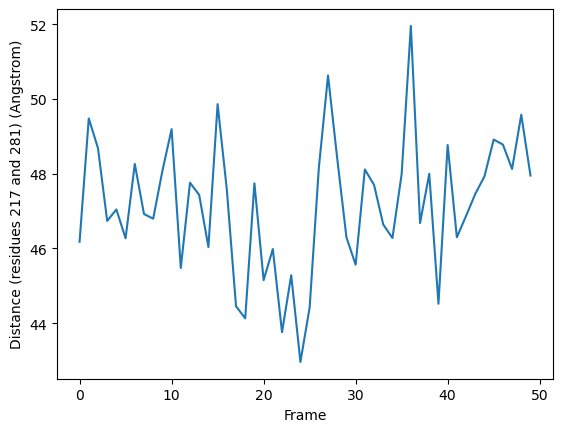

In [133]:
plt.plot(max_dists_dry)
plt.xlabel('Frame')
plt.ylabel('Distance (residues 217 and 281) (Angstrom)')